In [78]:
import glob
import numpy as np
import matplotlib.pyplot as plt

DATA_ROOT = "../../data/sonics/attack/train"   # relatif au notebook
AI_MODEL  = "udio_v120"

# Charge tous les npz AI + human
def load_npz_dir(path):
    fps, sfs = [], []
    for f in sorted(glob.glob(f"{path}/*.npz")):
        d = np.load(f)
        fps.append(d["stft"])           # (N, 8193) — already fakeprints
        sfs.append(d["speed_factors"])  # (N,)
    fps = np.concatenate(fps, axis=0)
    sfs = np.concatenate(sfs, axis=0)
    return fps, sfs

ai_fp, ai_sf    = load_npz_dir(f"{DATA_ROOT}/{AI_MODEL}")
human_fp, human_sf = load_npz_dir(f"{DATA_ROOT}/human")

# Load metadata from first file
d0 = np.load(sorted(glob.glob(f"{DATA_ROOT}/{AI_MODEL}/*.npz"))[0])
SR, N_FFT = int(d0["sampling_rate"]), int(d0["n_fft"])
FREQ_RANGE = [500, 5000]

# Linear freq axis: 0 → SR/2 in N_FFT//2+1 bins
freqs = np.linspace(0, SR / 2, N_FFT // 2 + 1)  # Hz

print(f"AI: {ai_fp.shape}, Human: {human_fp.shape}")
print(f"SR={SR}, N_FFT={N_FFT}, freq axis: {freqs[0]:.0f}–{freqs[-1]:.0f} Hz")

AI: (16828, 8193), Human: (19909, 8193)
SR=16000, N_FFT=16384, freq axis: 0–8000 Hz


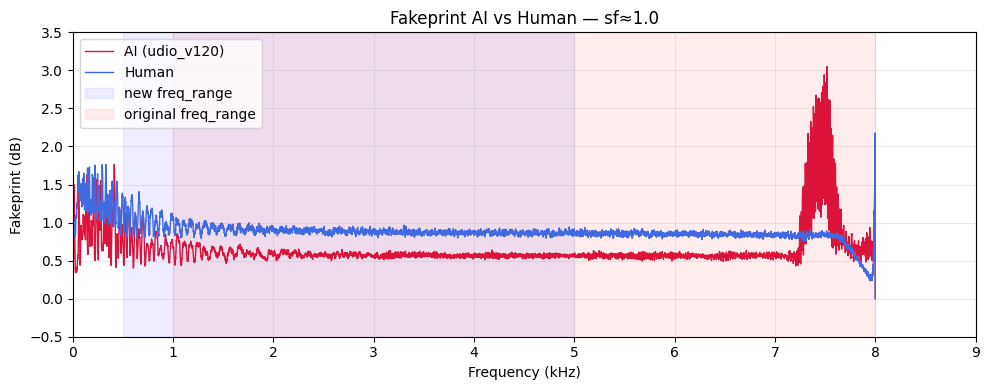

In [79]:
def mean_fp_near_sf(fp, sf, target, tol=0.02):
    mask = np.abs(sf - target) < tol
    return fp[mask].mean(axis=0)

fig, ax = plt.subplots(figsize=(10, 4))

for fps, sfs, label, c in [(ai_fp, ai_sf, f"AI ({AI_MODEL})", "crimson"), (human_fp, human_sf, "Human", "royalblue")]:
    avg = mean_fp_near_sf(fps, sfs, target=1.0)
    ax.plot(freqs / 1000, avg, lw=1.0, label=label, color=c)


ax.axvspan(FREQ_RANGE[0]/1000, FREQ_RANGE[1]/1000, alpha=0.07, color="blue", label="new freq_range")
ax.axvspan(1, 8, alpha=0.07, color="red", label="original freq_range")
ax.set_xlabel("Frequency (kHz)")
ax.set_ylabel("Fakeprint (dB)")
ax.set_xlim(0, SR / 2 / 1000 + 1)
ax.set_ylim(-0.5, 3.5)
ax.set_title("Fakeprint AI vs Human — sf≈1.0")
ax.legend()
ax.grid(True, lw=0.4, alpha=0.5)
plt.tight_layout()

# Save *before* plt.show(), to prevent saving a blank figure
plt.savefig(f"../../outputs/fakeprints/{AI_MODEL}.png", dpi=300)
plt.show()

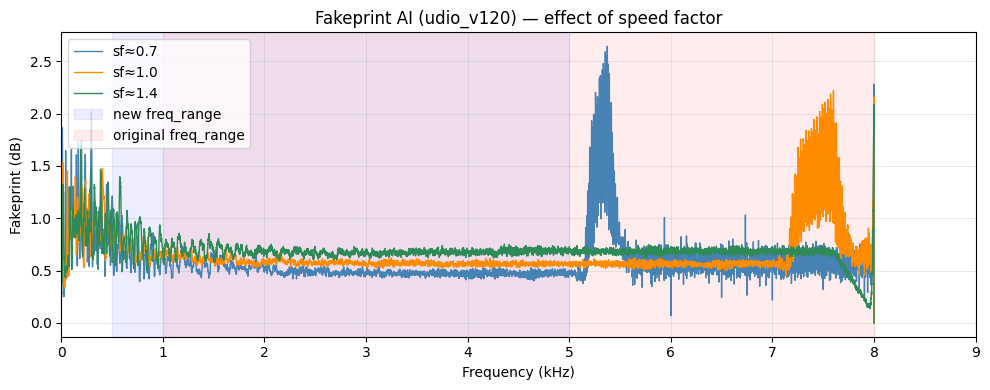

In [80]:
targets = [0.7, 1.0, 1.4]
colors  = ["steelblue", "darkorange", "seagreen"]

fig, ax = plt.subplots(figsize=(10, 4))

for sf_t, c in zip(targets, colors):
    avg = mean_fp_near_sf(ai_fp, ai_sf, target=sf_t, tol=0.03)
    ax.plot(freqs / 1000, avg, lw=1.0, label=f"sf≈{sf_t}", color=c)

# Show both the "new" and "original" freq ranges as in the earlier cell
ax.axvspan(FREQ_RANGE[0]/1000, FREQ_RANGE[1]/1000, alpha=0.07, color="blue", label="new freq_range")
ax.axvspan(1, 8, alpha=0.07, color="red", label="original freq_range")
ax.set_xlabel("Frequency (kHz)")
ax.set_ylabel("Fakeprint (dB)")
ax.set_xlim(0, SR / 2 / 1000 + 1)
ax.set_title(f"Fakeprint AI ({AI_MODEL}) — effect of speed factor")
ax.legend()
ax.grid(True, lw=0.4, alpha=0.5)
plt.tight_layout()
plt.savefig(f"../../outputs/fakeprints/{AI_MODEL}_speed.png", dpi=300)
plt.show()
